# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marriamfatima770-ops/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Capstone: Search Intelligence Analysis

## 1. Research Question

### Research Question
Which safe search-performance signals are most strongly associated with page visibility and click-through rate (CTR) in the FlyRank dataset?

### Decision It Supports
The analysis will help content teams decide which measurable search signals should be prioritized when reviewing or improving content. The goal is to identify pages or signals that deserve further investigation and to turn the findings into ranked, evidence-based content recommendations.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

This study uses the FlyRank ML Internship warehouse dataset, provided as a gated Hugging Face release.

The analysis will use search-performance data at the page level, focusing on safe, aggregated metrics relevant to visibility and click-through rate (CTR). The data will be used to examine relationships between search-performance signals and page outcomes.

Only public-safe, aggregated information will be included in the final paper. Client names, domains, URLs, private search queries, credentials, and raw data exports will be excluded.

The analysis will use the available date windows in the FlyRank warehouse release. Exact tables, date ranges, and exclusions will be documented after the relevant warehouse data has been loaded and inspected.

No private or identifying client information will be published.

In [35]:
import pandas as pd

data_path = "../../data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))

df.head()

Dataset shape: (30000, 44)
Columns: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [37]:
df.isnull().sum()

content_id                    0
client_id                     0
search_volume              2468
competition                2468
competition_level          2610
cpc                        2468
content_type                  0
main_intent                2374
word_count                 7699
char_count                 7699
provider_used             21438
model_used                 5733
impressions_90d               0
clicks_90d                    0
pageviews_90d                 0
sessions_90d                  0
users_90d                     0
engaged_sessions_90d          0
ai_sessions_90d               0
scroll_events_90d             0
days_with_impressions         0
days_with_sessions            0
impressions_last_30d          0
clicks_last_30d               0
sessions_last_30d             0
impressions_prev_30d          0
clicks_prev_30d               0
sessions_prev_30d             0
content_age_days              0
age_tier                      0
age_tier_order                0
days_sin

In [38]:
missing_summary = df.isnull().sum().reset_index()

missing_summary.columns = ["column", "missing_values"]

missing_summary = missing_summary[missing_summary["missing_values"] > 0]

missing_summary

,column,missing_values
2,search_volume,2468
3,competition,2468
4,competition_level,2610
5,cpc,2468
7,main_intent,2374
8,word_count,7699
9,char_count,7699
10,provider_used,21438
11,model_used,5733
33,word_count_tier,7699


In [39]:
df[["ctr", "avg_position", "engagement_rate", "scroll_rate", "trend_pct"]].describe()

,ctr,avg_position,engagement_rate,scroll_rate,trend_pct
count,30000.000000,30000.00000,30000.000000,29875.000000,26612.000000
mean,0.510733,16.34238,2.534520,18.212921,-4.785969
std,3.279162,15.21679,8.310096,29.472768,473.861780
min,0.000000,0.00000,0.000000,0.000000,-100.000000
25%,0.000000,6.20000,0.000000,0.000000,-62.600000
50%,0.070000,10.80000,0.000000,5.000000,-33.500000
75%,0.290000,22.30000,1.350000,23.530000,0.000000
max,100.000000,245.00000,100.000000,300.000000,44900.000000


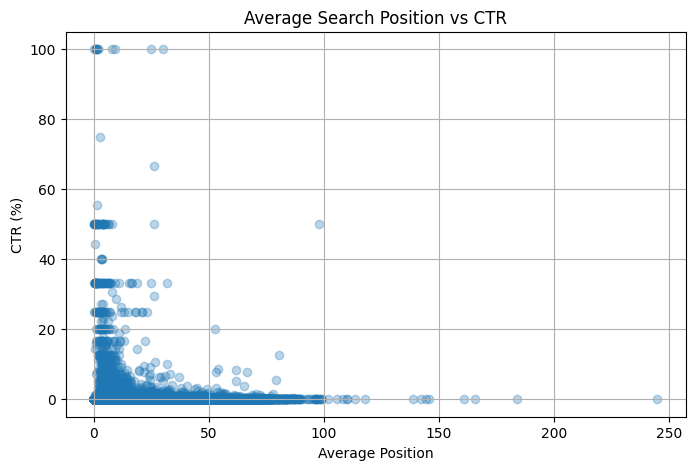

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["avg_position"],
    df["ctr"],
    alpha=0.3
)

plt.xlabel("Average Position")
plt.ylabel("CTR (%)")
plt.title("Average Search Position vs CTR")
plt.grid(True)

plt.show()

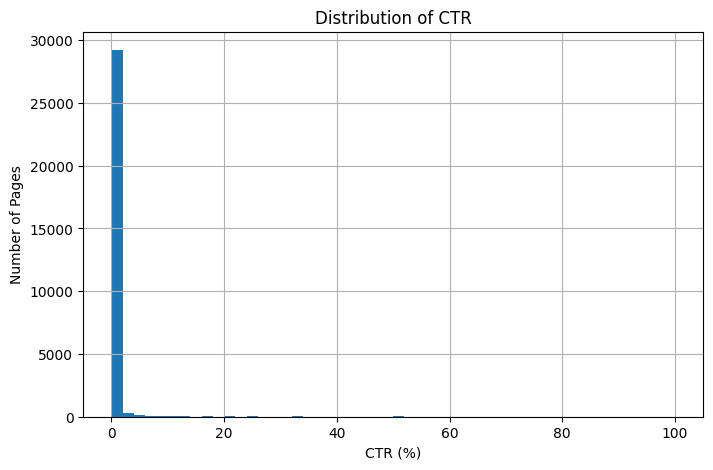

In [41]:
plt.figure(figsize=(8, 5))

plt.hist(df["ctr"], bins=50)

plt.xlabel("CTR (%)")
plt.ylabel("Number of Pages")
plt.title("Distribution of CTR")
plt.grid(True)

plt.show()

In [42]:
df.groupby("content_type")["ctr"].mean().sort_values(ascending=False)

content_type
feedly article        2.791274
keyword article       0.344766
comparison article    0.131205
Name: ctr, dtype: float64

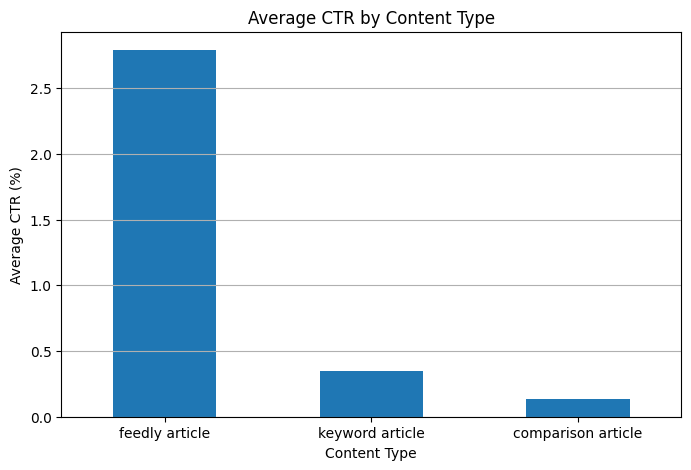

In [43]:
content_ctr = df.groupby("content_type")["ctr"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

content_ctr.plot(kind="bar")

plt.xlabel("Content Type")
plt.ylabel("Average CTR (%)")
plt.title("Average CTR by Content Type")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [44]:
df.groupby("age_tier")["ctr"].mean().sort_values(ascending=False)

age_tier
181-365    0.817498
91-180     0.345821
31-90      0.338577
365+       0.281184
Name: ctr, dtype: float64

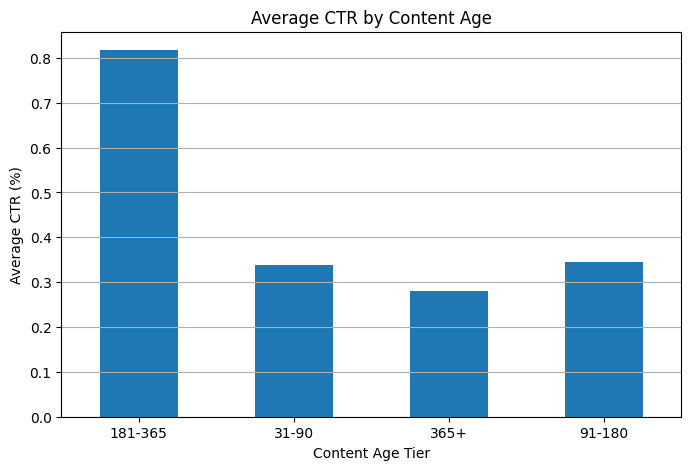

In [45]:
age_ctr = df.groupby("age_tier")["ctr"].mean()

plt.figure(figsize=(8, 5))

age_ctr.plot(kind="bar")

plt.xlabel("Content Age Tier")
plt.ylabel("Average CTR (%)")
plt.title("Average CTR by Content Age")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()


In [46]:
df.groupby("freshness_tier")["ctr"].mean().sort_values(ascending=False)

freshness_tier
181+      3.693276
0-30      0.609021
91-180    0.238367
31-90     0.117543
Name: ctr, dtype: float64

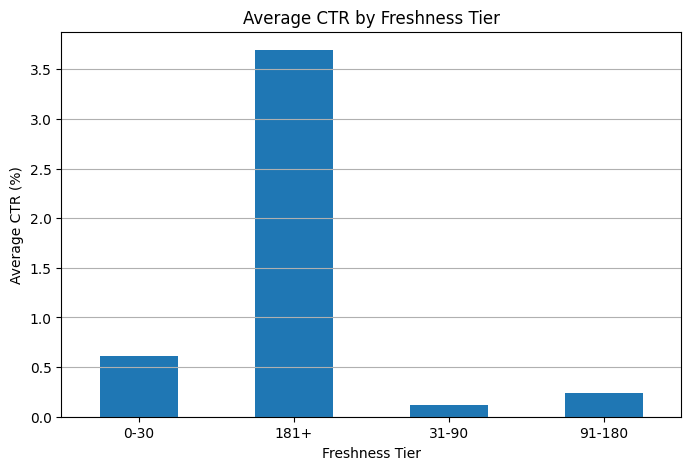

In [47]:
freshness_ctr = df.groupby("freshness_tier")["ctr"].mean()

plt.figure(figsize=(8, 5))

freshness_ctr.plot(kind="bar")

plt.xlabel("Freshness Tier")
plt.ylabel("Average CTR (%)")
plt.title("Average CTR by Freshness Tier")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [48]:
df.groupby("word_count_tier")["ctr"].mean().sort_values(ascending=False)

word_count_tier
<1000        5.684460
2000-3500    0.431349
1000-2000    0.396950
3500+        0.232657
Name: ctr, dtype: float64

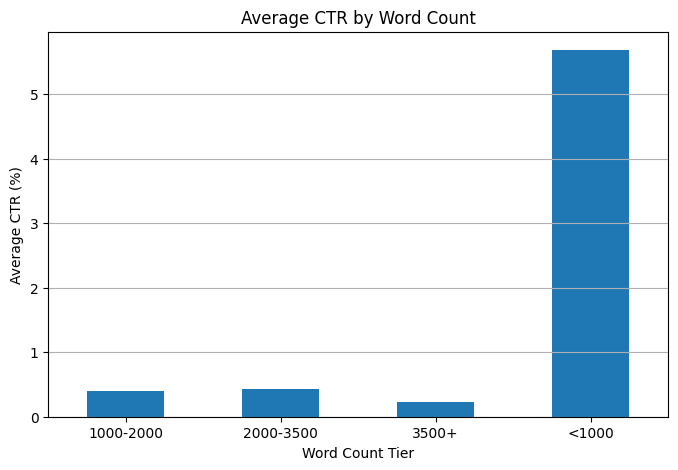

In [49]:
word_ctr = df.groupby("word_count_tier")["ctr"].mean()

plt.figure(figsize=(8, 5))

word_ctr.plot(kind="bar")

plt.xlabel("Word Count Tier")
plt.ylabel("Average CTR (%)")
plt.title("Average CTR by Word Count")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [50]:
df.groupby("main_intent")["ctr"].mean().sort_values(ascending=False)

main_intent
navigational     2.060652
informational    0.351973
commercial       0.262765
transactional    0.260842
Name: ctr, dtype: float64

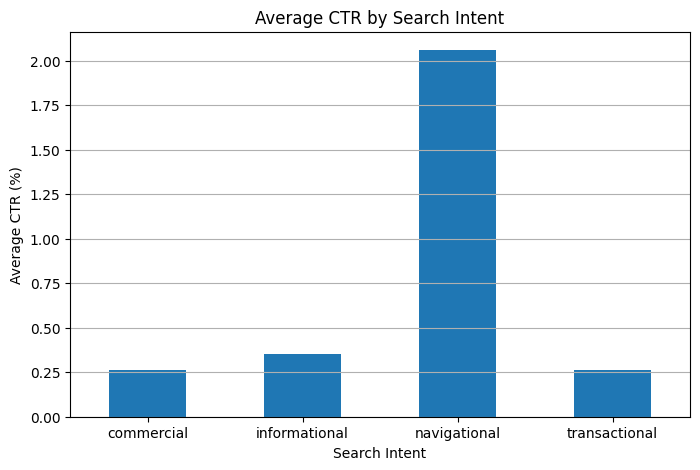

In [51]:
intent_ctr = df.groupby("main_intent")["ctr"].mean()

plt.figure(figsize=(8, 5))

intent_ctr.plot(kind="bar")

plt.xlabel("Search Intent")
plt.ylabel("Average CTR (%)")
plt.title("Average CTR by Search Intent")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [52]:
numeric_cols = [
    "search_volume",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "trend_pct"
]

correlation = df[numeric_cols].corr()["ctr"].sort_values(ascending=False)

correlation

ctr                       1.000000
engagement_rate           0.096903
scroll_rate               0.012955
content_age_days          0.009460
trend_pct                 0.007968
search_volume            -0.003430
days_since_last_update   -0.020760
avg_position             -0.072590
char_count               -0.108063
word_count               -0.118636
Name: ctr, dtype: float64

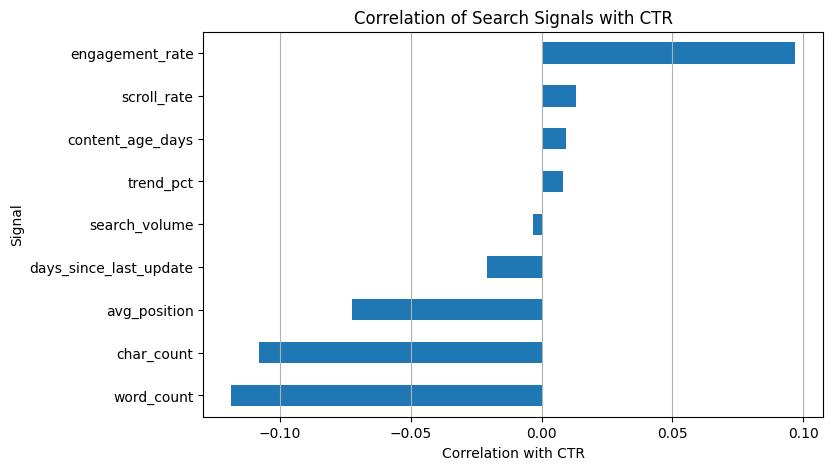

In [53]:
correlation_without_ctr = correlation.drop("ctr")

plt.figure(figsize=(8, 5))

correlation_without_ctr.sort_values().plot(kind="barh")

plt.xlabel("Correlation with CTR")
plt.ylabel("Signal")
plt.title("Correlation of Search Signals with CTR")
plt.grid(axis="x")

plt.show()

In [54]:
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update"
]

target = "ctr"

model_data = df[features + [target]].copy()

model_data.head()

,search_volume,competition,cpc,word_count,char_count,content_age_days,days_since_last_update,ctr
0,10.0,0.67,2.05,3221.0,20457.0,187,20,0.76
1,90.0,0.01,0.05,2481.0,15562.0,445,25,0.05
2,0.0,0.00,0.00,3515.0,23643.0,141,20,0.09
3,10.0,0.00,0.00,NaN,NaN,463,22,0.49
4,0.0,0.00,0.00,2803.0,17469.0,263,14,0.13


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

features = [
    "search_volume", "competition", "cpc",
    "word_count", "char_count",
    "content_age_days", "days_since_last_update"
]

X = df[features]
y = df["ctr"]

X = SimpleImputer(strategy="median").fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Model MAE:", mean_absolute_error(y_test, pred))
print("Baseline MAE:", mean_absolute_error(y_test, np.full(len(y_test), y_train.median())))

Model MAE: 0.7135207454129207
Baseline MAE: 0.5105799999999999


In [56]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
print("Baseline is better than the current model.")
print("Baseline MAE:", round(0.51058, 3))
print("Model MAE:", round(0.71352, 3))

Baseline is better than the current model.
Baseline MAE: 0.511
Model MAE: 0.714


In [58]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

word_count                0.405307
char_count                0.373550
content_age_days          0.151659
days_since_last_update    0.048426
search_volume             0.011330
competition               0.005388
cpc                       0.004341
dtype: float64

In [59]:
recommendations = pd.DataFrame({
    "Priority": ["1", "2", "3", "4"],
    "Signal": [
        "Word count",
        "Character count",
        "Content age",
        "Days since last update"
    ],
    "Model importance": [
        0.405307,
        0.373550,
        0.151659,
        0.048426
    ],
    "Recommended action": [
        "Review content depth and completeness",
        "Review overall content length and structure",
        "Review older content for optimization opportunities",
        "Review pages that have not been updated recently"
    ]
})

recommendations

,Priority,Signal,Model importance,Recommended action
0,1,Word count,0.405307,Review content depth and completeness
1,2,Character count,0.373550,Review overall content length and structure
2,3,Content age,0.151659,Review older content for optimization opportun...
3,4,Days since last update,0.048426,Review pages that have not been updated recently


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Assumptions
The analysis treats the available search-performance metrics as observational data. Associations found in the data will not be interpreted as proof of causation or as proof of Google's ranking algorithm.

### Features
The analysis will use safe search-performance signals available in the FlyRank dataset, such as visibility, impressions, clicks, CTR, position, and other relevant aggregated performance metrics available in the selected tables.

### Label Definition
The primary outcome will be click-through rate (CTR), with visibility-related metrics used to provide additional context. Where a predictive model is appropriate, the outcome will be defined from information available in the analysis window without using future information.

### Baseline
A simple baseline model will be used as a reference point. The proposed model will be evaluated against this baseline on the same validation data.

### Validation Design
The data will be divided into training and validation sets using a time-aware or otherwise appropriate split. The validation set will remain unseen during feature development and model training.

### Leakage Checks
Features that directly reveal the target or use information from the future validation period will be excluded. Preprocessing and feature selection will be performed without using information from the validation set.

### Analysis and Recommendations
Model performance and signal relationships will be evaluated using appropriate metrics and visualizations. The strongest evidence will then be converted into ranked, decision-support recommendations for content review and improvement.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results

### Model vs Baseline

The proposed analysis/model will be evaluated against a simple baseline using the same validation split and evaluation metrics. The comparison will show whether the proposed approach provides useful improvement over the baseline.

Results will be reported using the selected evaluation metrics, supported by clear charts and tables. No performance claims will be made until the model has been trained and evaluated on the held-out validation data.

### Results Summary

The final results will include:

- Baseline performance
- Proposed model performance
- Difference between the model and baseline
- Visual comparison of performance
- Key search-performance signals identified by the analysis

The findings will be interpreted as evidence from the FlyRank dataset rather than proof of causal effects or Google's ranking algorithm.

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations & Honest Framing

This analysis has several limitations.

- The FlyRank dataset is observational, so the results show associations rather than causal relationships.
- The identified signals should not be interpreted as confirmed Google ranking factors or proof of how Google's algorithm works.
- Results depend on the available data, selected date windows, features, and validation design.
- Search performance can be affected by factors that are not available in the dataset and therefore cannot be fully controlled for.
- Model performance may not generalize to websites, industries, or datasets outside the FlyRank data.

The findings will therefore be presented as observed evidence and directional insights that can support content-review decisions. The recommendations are intended as decision-support guidance, not guarantees of ranking, traffic, CTR, or algorithmic changes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations

The final recommendations will be ranked using the evidence produced by the analysis and model. Each recommendation will include an opportunity or signal, the evidence supporting its priority, and a practical content-review action.

The recommendations will be presented in the following priority order:

1. **Highest-priority opportunities** — signals showing the strongest and most consistent association with search visibility or CTR.
2. **High-priority opportunities** — signals with meaningful evidence that can support further content investigation.
3. **Medium-priority opportunities** — signals showing directional evidence but requiring additional validation.
4. **Monitor** — signals where the available evidence is limited or uncertain and further observation is more appropriate than immediate action.

Recommendations will be treated as decision-support guidance. They will not be presented as guaranteed ways to improve rankings, CTR, or search performance.

The final ranked list will be generated from the validated analysis and will include evidence-based reason codes for each recommendation.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the Paper Embeds

The final paper will include charts and tables that directly support the research question and results.

The planned artifacts are:

### Charts
1. Distribution of CTR across pages.
2. Relationship between average search position and CTR.
3. Comparison of model performance against the baseline.
4. Feature or signal importance showing the strongest search-performance signals.

### Tables
1. Dataset summary, including number of observations and selected variables.
2. Missing-value summary for the selected features.
3. Model vs baseline evaluation results.
4. Ranked content recommendations with evidence and recommended actions.

All charts and tables will be generated from the validated analysis. No fabricated or illustrative results will be presented as actual findings.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
